# Temporal Base-Rate Drift and Prior-Shift Risk

This notebook documents how 12-month attrition prevalence changes across the three synthetic historical periods and how that change relates to aggregate calibration transport.

> Every employee and outcome is synthetic. This is a post-evaluation, aggregate diagnostic. It does not recalibrate on the final test, change the selected model, change the frozen policy, or authorize automatic employment action.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT = PROJECT_ROOT / "data" / "processed" / "temporal_prior_shift"

base_rates = pd.read_csv(OUTPUT / "temporal_base_rate_summary.csv")
calibration = pd.read_csv(OUTPUT / "calibration_shift_summary.csv")
decomposition = pd.read_csv(OUTPUT / "prior_shift_decomposition.csv")
checks = pd.read_csv(OUTPUT / "validation_checks.csv")

print(f"Loaded aggregate prior-shift outputs from {OUTPUT.relative_to(PROJECT_ROOT)}")
print(f"Checks passed: {(checks['status'] == 'PASS').sum()}/{len(checks)}")

Loaded aggregate prior-shift outputs from data\processed\temporal_prior_shift
Checks passed: 12/12


## Historical base rates

The full historical rate rises from 9.62% to 10.42% to 11.91%. The model-eligible rates are shown separately because calibration is evaluated on that narrower population.

In [2]:
columns = [
    "cohort", "period", "rows", "positive_cases", "positive_rate",
    "absolute_change_from_first", "relative_change_from_first",
]
display(base_rates[columns].round(4))

,cohort,period,rows,positive_cases,positive_rate,absolute_change_from_first,relative_change_from_first
0,Full historical population,2023 train,4303,414,0.0962,0.0000,0.0000
1,Full historical population,2024 validation,5625,586,0.1042,0.0080,0.0828
2,Full historical population,2025 final test,6745,803,0.1191,0.0228,0.2374
3,Model-eligible population,2023 train,4206,414,0.0984,0.0000,0.0000
4,Model-eligible population,2024 validation,5521,586,0.1061,0.0077,0.0783
5,Model-eligible population,2025 final test,6641,803,0.1209,0.0225,0.2284


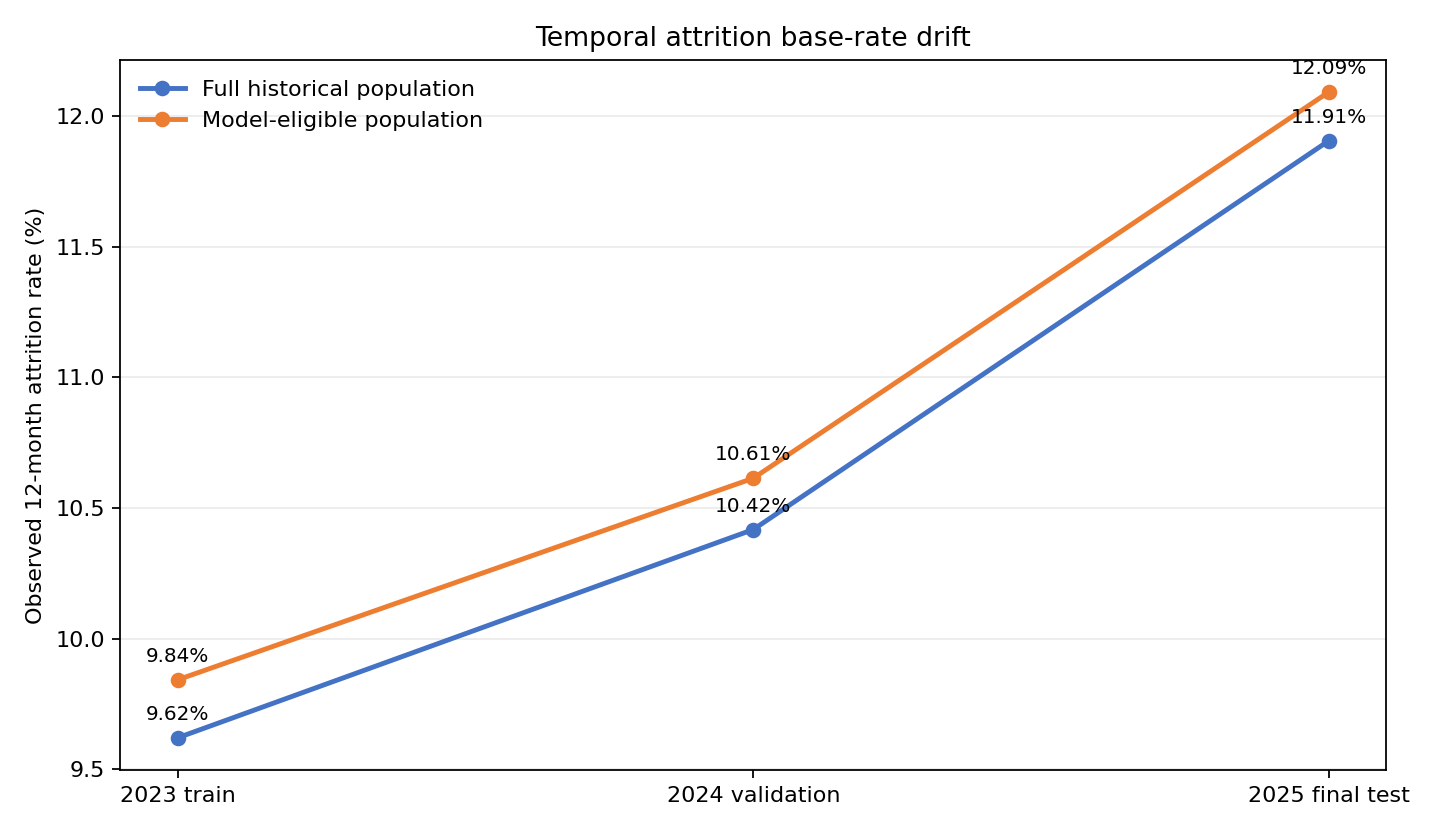

In [3]:
display(Image(filename=OUTPUT / "temporal_base_rate_drift.png"))

## Calibration transport

Sigmoid calibration is selected on the 2024 validation period. The final-test mean prediction rises with the later feature mix but remains below the 12.09% observed rate.

In [4]:
display(calibration[[
    "period", "evaluation_role", "rows", "positive_cases",
    "observed_attrition_rate", "mean_predicted_probability",
    "calibration_gap",
]].round(4))

,period,evaluation_role,rows,positive_cases,observed_attrition_rate,mean_predicted_probability,calibration_gap
0,2024 validation,Calibration selection,5521,586,0.1061,0.1002,-0.0059
1,2025 final test,Once-only frozen evaluation,6641,803,0.1209,0.1102,-0.0107


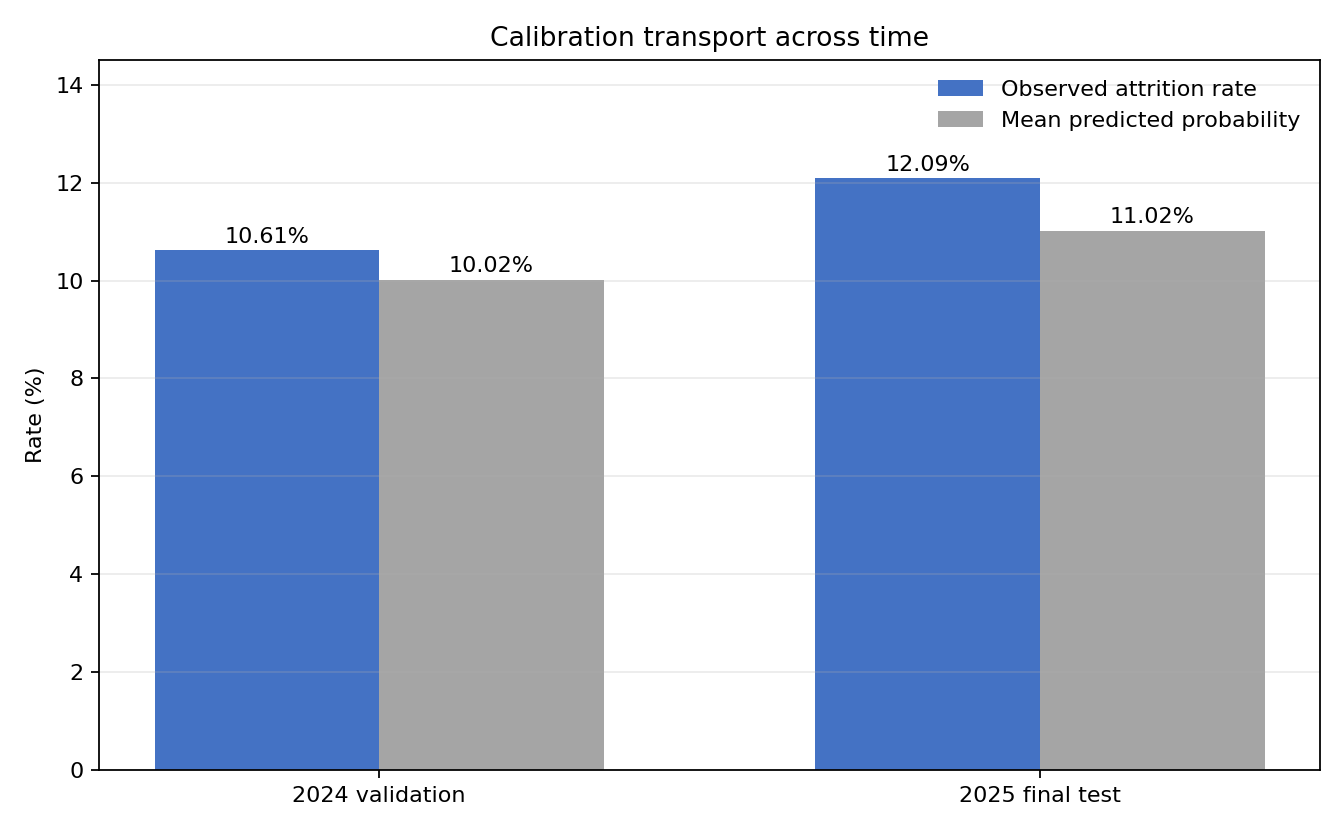

In [5]:
display(Image(filename=OUTPUT / "observed_vs_predicted_rate.png"))

## Prior-shift decomposition

Observed prevalence rises 1.478 percentage points from validation to final test, while the mean prediction rises 1.002 points. The remaining 0.476-point increase is exactly the deterioration in the aggregate calibration gap.

In [6]:
display(decomposition.round(4))

,source_period,target_period,observed_rate_change,observed_relative_change,predicted_mean_change,predicted_relative_change,untracked_prevalence_change,calibration_gap_change,prior_odds_multiplier,diagnostic_label,pure_label_shift_proven,final_test_adjustment_applied
0,2024 validation,2025 final test,0.0148,0.1392,0.01,0.1,0.0048,-0.0048,1.1584,prior-probability shift risk,False,False


## Interpretation and governance

The pattern is consistent with **prior-probability shift risk**, but prevalence alone does not prove pure label shift. Feature drift and relationship drift may also be present. The 12.09% final rate becomes known only after the outcome window matures, so it is not used to adjust final-test probabilities.

A real deployment would monitor matured outcome windows and evaluate any new recalibration on a later untouched period.

In [7]:
display(checks[["check", "status", "details"]])
assert checks["status"].eq("PASS").all()

,check,status,details
0,Full historical period counts reconcile,PASS,"The 9.62%, 10.42%, and 11.91% rates have expli..."
1,Full historical period rates reconcile,PASS,The previously undocumented full-population dr...
2,Model-eligible period counts reconcile,PASS,Calibration transport is evaluated on the actu...
3,Model-eligible period rates reconcile,PASS,"Train, validation, and final-test prevalence a..."
4,First-to-final full-population drift is material,PASS,Outcome prevalence rises about 23.74% relative...
5,Selected validation calibration aggregate reco...,PASS,Sigmoid calibration was selected on the 2024 v...
6,Once-only final-test aggregate reconciles,PASS,The audit reuses the frozen aggregate result i...
7,Validation-to-test prevalence shift is explicit,PASS,Model-eligible prevalence rises about 13.92% r...
8,Calibration-gap deterioration is arithmeticall...,PASS,Observed prevalence rose 0.476 percentage poin...
9,Prior-shift terminology remains qualified,PASS,Prevalence drift alone cannot establish stable...
